In [157]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
from sklearn.linear_model import SGDRegressor
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

In [158]:
x,y = load_diabetes(return_X_y=True)

In [159]:
print(x.shape) # 442 rows 10 columns 
print(y.shape) # 442 rows 

(442, 10)
(442,)


### first i'm implementing the linear_regression

In [160]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [161]:
x_train , x_test , y_train , y_test = train_test_split(x, y ,test_size=0.3, random_state=42)

In [162]:
lr = LinearRegression()

In [163]:
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)
r2_score(y_test,lr_pred)

0.4772897164322618

## now implementing it in SGD from scratch

np.ones(n)
Creates a 1D array of n values, all set to 1. Used to initialize coefficients because starting at non-zero values breaks symmetry — all features get a chance to update independently from the first step.
np.dot(A, B)
Computes the dot product. For ML use cases:

np.dot(X_train, coef_) — multiplies each feature by its coefficient and sums them up for every row. Equivalent to m1*x1 + m2*x2 + ... + m10*x10 for all rows at once. Returns a 1D array of predictions.
np.dot(residuals, X_train) — used in gradient calculation to get one gradient value per feature.

Why not simple multiplication (*) for predictions?
self.m * X_test with multiple features causes numpy to broadcast incorrectly, giving a 2D array instead of 1D predictions. np.dot() handles the matrix math correctly.

In [164]:
x_train.shape
x_train.shape[0]
x = x_train
rand_row = np.random.randint(0 ,x_train.shape[0] )
print(x[rand_row].ravel())
print(rand_row)

[ 0.02717829 -0.04464164  0.04984027 -0.05500648 -0.00294491  0.04064802
 -0.0581274   0.05275942 -0.05296264 -0.0052198 ]
146


In [165]:


class SelfSGD():

    def __init__(self, lr = 0.01 , epoches = 50):
        self.lr = lr
        self.epoches = epoches 
        self.m= None
        self.b = 0 

    def fit(self , x_train , y_train):

        self.m = np.ones(x_train.shape[1],)

        x = x_train
        y = y_train

        for num in range(self.epoches):

            for rows in range(x_train.shape[0]):

                # i wanna select the random row 
                rand_row = np.random.randint(0 ,x_train.shape[0] )

                loss_m = -2 * np.mean(y[rand_row] - self.m*x[rand_row].ravel() - self.b)*x[rand_row].ravel()
                loss_b = -2 * np.mean(y[rand_row] - self.m*x[rand_row].ravel() - self.b)

                self.m = self.m - self.lr * loss_m
                self.b = self.b - self.lr * loss_b

    def predict(self , x_test ):

        return np.dot(x_test ,self.m)+ self.b





In [166]:
My_SGD = SelfSGD(lr=0.001, epoches=200)
SGD = SGDRegressor()


In [167]:
My_SGD.fit(x_train,y_train)
SGD.fit(x_train,y_train)

a:\FINAL_CODING_FILE\machine_learning\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [168]:
my_pred = My_SGD.predict(x_test)
y_pred = SGD.predict(x_test)

In [169]:
print(my_pred)
print(y_pred)

[182.48958899 157.36711701 175.09462774 274.42169459 162.72014163
 141.57865603 232.43636772 219.47893917 115.29613159 146.11824259
 117.55526098 130.53175567  64.82398052 217.83018399 127.731206
 131.79434937 225.79655392 245.35608768 153.54459036 212.44827477
 167.49151423 120.6763614   92.09325121 193.44372459 137.54643174
 171.27977701 180.47310187 177.53543574  61.96122035 156.02073842
 176.69099181 110.14729756 152.26584204 190.08260697 188.10163902
 194.1387251  150.08178109 162.04526214 189.52283323  80.8892855
 105.24812393 132.90821716 152.53514357 188.60485342 168.61800005
  87.51684364  89.98214049  94.6023676   75.92636369 138.23690873
 117.47088185  77.93125967 151.75433842 117.35016245 206.35724969
 130.20869489 126.43717408 182.96142999 113.40445914  68.1473783
 198.42983962 164.99226441 131.50315161 138.60291517 140.57199177
 188.33080118 196.22064725 166.90190311  91.14937707 153.70597776
 174.30877668 213.05852771 241.51608217 144.93054466  95.78650163
 189.40661062 

In [170]:
print("my SGD r2_score ",r2_score(y_test,my_pred))
print("sklearn SGD r2_score ",r2_score(y_test,y_pred))
print("lr r2_score = ",r2_score(y_test,lr_pred) )

my SGD r2_score  0.41875526633727156
sklearn SGD r2_score  0.4165815624930994
lr r2_score =  0.4772897164322618


### implementing the graph to better visualise it

ValueError: x and y must be the same size

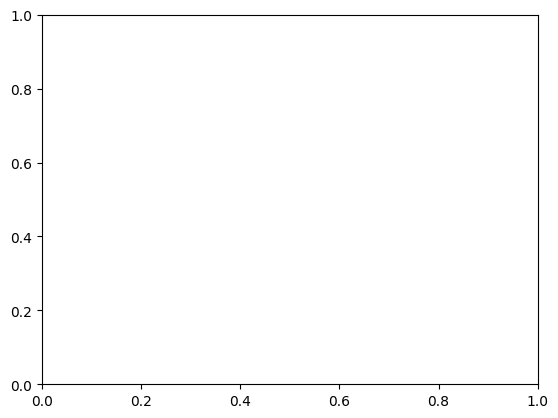